In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load the Dataset

### What we're doing
Loading the pre-cleaned AquaSat dataset from the local file system.

### What to verify
- File loads without errors
- Number of records matches expectation (~57,000)
- No immediate read errors or encoding issues

In [2]:
# Load the dataset
DATA_PATH = '../dataset_with_all_targets_present.csv'

print("Loading AquaSat dataset...")
df = pd.read_csv(DATA_PATH)

print(f"\n✅ Dataset loaded successfully!")
print(f"\n{'='*60}")
print(f"DATASET SHAPE:")
print(f"{'='*60}")
print(f"  • Number of records: {df.shape[0]:,}")
print(f"  • Number of features: {df.shape[1]}")
print(f"  • Total cells: {df.shape[0] * df.shape[1]:,}")

Loading AquaSat dataset...

✅ Dataset loaded successfully!

DATASET SHAPE:
  • Number of records: 57,268
  • Number of features: 45
  • Total cells: 2,577,060


In [3]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
print("="*100)
df.head()


First 5 rows of the dataset:


,system:index,SiteID,blue,blue_sd,date_unity,green,green_sd,nir,nir_sd,path,pixelCount,qa,qa_sd,red,red_sd,row,sat,swir1,swir1_sd,swir2,swir2_sd,.geo,endtime,date,date_only,chl_a,p_sand,secchi,tss,source,lat,long,TZID,date_utc,clouds,time,landsat_id,timediff,pwater,type,id,wq_pattern,date_parsed,year,month
0,4334,1111REG1-CRBL06,263.000,22.873,2003-08-19T12:00:00Z,255.000,20.546,289.000,57.338,12,55,68.000,0.374,213.000,26.313,31,7,70.000,54.697,37.000,38.038,"{""type"":""Point"",""coordinates"":[-71.10631,42.35...",00:00:00,2003-08-19,True,18.000,NaN,1.000,6.800,WQP,42.353,-71.106,America/New_York,2003-08-19T16:00:00Z,1.000,2003-08-19T15:15:31Z,LE07_L1TP_012031_20030819_20160927_01_T1,0.741,95.000,Stream,New,111,2003-08-19,2003,8
1,4341,1111REG1-CRBL06,365.000,25.951,2000-09-12T09:15:00Z,390.000,25.848,392.000,61.404,12,55,68.000,0.519,302.000,31.832,31,7,100.000,45.829,65.000,35.290,"{""type"":""Point"",""coordinates"":[-71.10631,42.35...",09:15:00,2000-09-11,False,34.200,NaN,1.000,7.000,WQP,42.353,-71.106,UTC,2000-09-12T09:15:00Z,20.000,2000-09-11T15:17:47Z,LE07_L1TP_012031_20000911_20161002_01_T1,17.954,95.000,Stream,New,111,2000-09-11,2000,9
2,4342,1111REG1-CRBL06,345.000,32.336,2002-09-10T12:43:30Z,401.000,28.903,253.000,57.465,12,55,68.000,0.267,278.000,29.454,31,5,87.000,57.767,58.000,37.211,"{""type"":""Point"",""coordinates"":[-71.10631,42.35...",12:43:30,2002-09-09,False,19.400,NaN,1.000,7.800,WQP,42.353,-71.106,UTC,2002-09-10T12:43:30Z,0.000,2002-09-09T15:01:09Z,LT05_L1TP_012031_20020909_20160916_01_T1,21.706,95.000,Stream,New,111,2002-09-09,2002,9
3,4349,1111REG1-CRBL07,266.000,19.722,2003-08-19T12:00:00Z,238.000,21.296,209.000,58.567,12,59,68.000,0.000,178.000,23.786,31,7,47.000,35.896,38.000,29.618,"{""type"":""Point"",""coordinates"":[-71.0877256,42....",00:00:00,2003-08-19,True,20.000,NaN,1.200,6.800,WQP,42.353,-71.088,America/New_York,2003-08-19T16:00:00Z,1.000,2003-08-19T15:15:31Z,LE07_L1TP_012031_20030819_20160927_01_T1,0.741,96.000,Stream,New,111,2003-08-19,2003,8
4,4357,1111REG1-CRBL07,321.000,28.713,2002-09-10T09:57:04Z,401.000,28.898,253.000,47.754,12,59,68.000,0.258,278.000,31.571,31,5,58.000,47.060,58.000,49.379,"{""type"":""Point"",""coordinates"":[-71.0877256,42....",09:57:04,2002-09-09,False,13.100,NaN,1.200,6.200,WQP,42.353,-71.088,UTC,2002-09-10T09:57:04Z,0.000,2002-09-09T15:01:09Z,LT05_L1TP_012031_20020909_20160916_01_T1,18.932,96.000,Stream,New,111,2002-09-09,2002,9


In [4]:
# Display column names
print(f"\n{'='*60}")
print(f"ALL COLUMNS ({len(df.columns)} total):")
print(f"{'='*60}")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")


ALL COLUMNS (45 total):
  1. system:index
  2. SiteID
  3. blue
  4. blue_sd
  5. date_unity
  6. green
  7. green_sd
  8. nir
  9. nir_sd
 10. path
 11. pixelCount
 12. qa
 13. qa_sd
 14. red
 15. red_sd
 16. row
 17. sat
 18. swir1
 19. swir1_sd
 20. swir2
 21. swir2_sd
 22. .geo
 23. endtime
 24. date
 25. date_only
 26. chl_a
 27. p_sand
 28. secchi
 29. tss
 30. source
 31. lat
 32. long
 33. TZID
 34. date_utc
 35. clouds
 36. time
 37. landsat_id
 38. timediff
 39. pwater
 40. type
 41. id
 42. wq_pattern
 43. date_parsed
 44. year
 45. month


## 2. Feature Categorization

### What we're doing
Organizing features into logical categories for better understanding.

### Why this matters
- Helps identify which features to use for modeling
- Clarifies the role of each variable
- Guides feature engineering decisions

In [5]:
# Define feature categories based on dataset exploration

# Target variables (water quality parameters) - USED FOR CLASS DERIVATION ONLY
TARGET_PARAMS = ['chl_a', 'tss', 'secchi']

# Spectral band reflectances (primary features)
SPECTRAL_BANDS = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

# Standard deviations of spectral bands
SPECTRAL_SD = ['blue_sd', 'green_sd', 'red_sd', 'nir_sd', 'swir1_sd', 'swir2_sd']

# Satellite/Scene metadata
SATELLITE_META = ['sat', 'path', 'row', 'pixelCount', 'clouds', 'pwater', 'qa', 'qa_sd']

# Temporal features
TEMPORAL_FEATURES = ['date', 'date_parsed', 'date_only', 'date_unity', 
                     'date_utc', 'time', 'endtime', 'timediff', 'year', 'month']

# Spatial features
SPATIAL_FEATURES = ['lat', 'long', 'type', 'TZID', '.geo']

# Identifier columns
ID_COLUMNS = ['system:index', 'SiteID', 'landsat_id', 'id', 'source', 'wq_pattern']

# Print categorization summary
print(f"{'='*60}")
print(f"FEATURE CATEGORIZATION SUMMARY")
print(f"{'='*60}")
print(f"\n📊 Target Parameters (for class derivation): {len(TARGET_PARAMS)}")
print(f"   {TARGET_PARAMS}")
print(f"\n🌈 Spectral Bands: {len(SPECTRAL_BANDS)}")
print(f"   {SPECTRAL_BANDS}")
print(f"\n📏 Spectral Standard Deviations: {len(SPECTRAL_SD)}")
print(f"   {SPECTRAL_SD}")
print(f"\n🛰️ Satellite Metadata: {len(SATELLITE_META)}")
print(f"   {SATELLITE_META}")
print(f"\n📅 Temporal Features: {len(TEMPORAL_FEATURES)}")
print(f"\n📍 Spatial Features: {len(SPATIAL_FEATURES)}")
print(f"\n🆔 Identifier Columns: {len(ID_COLUMNS)}")

FEATURE CATEGORIZATION SUMMARY

📊 Target Parameters (for class derivation): 3
   ['chl_a', 'tss', 'secchi']

🌈 Spectral Bands: 6
   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

📏 Spectral Standard Deviations: 6
   ['blue_sd', 'green_sd', 'red_sd', 'nir_sd', 'swir1_sd', 'swir2_sd']

🛰️ Satellite Metadata: 8
   ['sat', 'path', 'row', 'pixelCount', 'clouds', 'pwater', 'qa', 'qa_sd']

📅 Temporal Features: 10

📍 Spatial Features: 5

🆔 Identifier Columns: 6


## 3. Data Type Verification

### What we're doing
Checking that each column has the appropriate data type.

### What to verify
- Numeric columns are float/int
- Categorical columns are object/category
- Date columns can be parsed

In [6]:
# Check data types
print(f"{'='*60}")
print(f"DATA TYPE SUMMARY")
print(f"{'='*60}")

dtype_counts = df.dtypes.value_counts()
print("\nData type distribution:")
for dtype, count in dtype_counts.items():
    print(f"  • {dtype}: {count} columns")

print("\n" + "-"*60)
print("Detailed column data types:")
print("-"*60)
df.dtypes

DATA TYPE SUMMARY

Data type distribution:
  • float64: 23 columns
  • object: 13 columns
  • int64: 8 columns
  • bool: 1 columns

------------------------------------------------------------
Detailed column data types:
------------------------------------------------------------


system:index      int64
SiteID           object
blue            float64
blue_sd         float64
date_unity       object
green           float64
green_sd        float64
nir             float64
nir_sd          float64
path              int64
pixelCount        int64
qa              float64
qa_sd           float64
red             float64
red_sd          float64
row               int64
sat               int64
swir1           float64
swir1_sd        float64
swir2           float64
swir2_sd        float64
.geo             object
endtime          object
date             object
date_only          bool
chl_a           float64
p_sand          float64
secchi          float64
tss             float64
source           object
lat             float64
long            float64
TZID             object
date_utc         object
clouds          float64
time             object
landsat_id       object
timediff        float64
pwater          float64
type             object
id               object
wq_pattern      

In [7]:
# Verify spectral bands are numeric
print(f"\n{'='*60}")
print(f"SPECTRAL BAND DATA TYPE VERIFICATION")
print(f"{'='*60}")

all_spectral = SPECTRAL_BANDS + SPECTRAL_SD
spectral_dtypes = df[all_spectral].dtypes

print("\nSpectral feature data types:")
for col in all_spectral:
    dtype = df[col].dtype
    status = "✅" if np.issubdtype(dtype, np.number) else "❌ ISSUE"
    print(f"  {status} {col}: {dtype}")


SPECTRAL BAND DATA TYPE VERIFICATION

Spectral feature data types:
  ✅ blue: float64
  ✅ green: float64
  ✅ red: float64
  ✅ nir: float64
  ✅ swir1: float64
  ✅ swir2: float64
  ✅ blue_sd: float64
  ✅ green_sd: float64
  ✅ red_sd: float64
  ✅ nir_sd: float64
  ✅ swir1_sd: float64
  ✅ swir2_sd: float64


In [8]:
# Verify target parameters are numeric
print(f"\n{'='*60}")
print(f"TARGET PARAMETER DATA TYPE VERIFICATION")
print(f"{'='*60}")

print("\nTarget parameter data types:")
for col in TARGET_PARAMS:
    dtype = df[col].dtype
    status = "✅" if np.issubdtype(dtype, np.number) else "❌ ISSUE"
    print(f"  {status} {col}: {dtype}")


TARGET PARAMETER DATA TYPE VERIFICATION

Target parameter data types:
  ✅ chl_a: float64
  ✅ tss: float64
  ✅ secchi: float64


## 4. Missing Value Analysis

### What we're doing
Identifying columns with missing values and understanding the extent of missingness.

### Critical Note
Since this is a **cleaned dataset with all targets present**, we expect:
- chl_a, tss, secchi should have **NO** missing values
- Spectral bands should have minimal/no missing values

In [9]:
# Calculate missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100)
})

missing_df = missing_df.sort_values('Missing %', ascending=False)

print(f"{'='*60}")
print(f"MISSING VALUE ANALYSIS")
print(f"{'='*60}")

# Show columns with missing values
missing_cols = missing_df[missing_df['Missing Count'] > 0]

if len(missing_cols) > 0:
    print(f"\n⚠️ Columns with missing values ({len(missing_cols)} total):")
    print("-"*60)
    for _, row in missing_cols.iterrows():
        print(f"  • {row['Column']}: {row['Missing Count']:,} ({row['Missing %']:.2f}%)")
else:
    print("\n✅ No missing values found in any column!")

MISSING VALUE ANALYSIS

⚠️ Columns with missing values (8 total):
------------------------------------------------------------
  • p_sand: 57,268 (100.00%)
  • blue_sd: 440 (0.77%)
  • green_sd: 440 (0.77%)
  • nir_sd: 440 (0.77%)
  • swir2_sd: 440 (0.77%)
  • swir1_sd: 440 (0.77%)
  • qa_sd: 440 (0.77%)
  • red_sd: 440 (0.77%)


In [10]:
# Critical check: Target parameters should have NO missing values
print(f"\n{'='*60}")
print(f"CRITICAL CHECK: TARGET PARAMETER COMPLETENESS")
print(f"{'='*60}")

target_missing = df[TARGET_PARAMS].isnull().sum()

all_targets_complete = True
for param in TARGET_PARAMS:
    missing = target_missing[param]
    if missing == 0:
        print(f"  ✅ {param}: Complete (0 missing)")
    else:
        print(f"  ❌ {param}: {missing:,} missing values")
        all_targets_complete = False

if all_targets_complete:
    print(f"\n🎉 All target parameters are complete - ready for class derivation!")
else:
    print(f"\n⚠️ WARNING: Some target parameters have missing values!")


CRITICAL CHECK: TARGET PARAMETER COMPLETENESS
  ✅ chl_a: Complete (0 missing)
  ✅ tss: Complete (0 missing)
  ✅ secchi: Complete (0 missing)

🎉 All target parameters are complete - ready for class derivation!


In [11]:
# Check spectral bands for missing values
print(f"\n{'='*60}")
print(f"SPECTRAL BAND COMPLETENESS CHECK")
print(f"{'='*60}")

spectral_missing = df[SPECTRAL_BANDS].isnull().sum()

for band in SPECTRAL_BANDS:
    missing = spectral_missing[band]
    pct = missing / len(df) * 100
    status = "✅" if missing == 0 else "⚠️"
    print(f"  {status} {band}: {missing:,} missing ({pct:.2f}%)")


SPECTRAL BAND COMPLETENESS CHECK
  ✅ blue: 0 missing (0.00%)
  ✅ green: 0 missing (0.00%)
  ✅ red: 0 missing (0.00%)
  ✅ nir: 0 missing (0.00%)
  ✅ swir1: 0 missing (0.00%)
  ✅ swir2: 0 missing (0.00%)


## 5. Target Variable Statistics

### What we're doing
Examining the distribution of our three water quality parameters.

### Why this matters
- Understanding value ranges helps set reasonable thresholds
- Identifying outliers that might affect classification
- Confirming data makes physical/scientific sense

In [12]:
# Summary statistics for target variables
print(f"{'='*60}")
print(f"TARGET VARIABLE SUMMARY STATISTICS")
print(f"{'='*60}")

target_stats = df[TARGET_PARAMS].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("\n")
target_stats

TARGET VARIABLE SUMMARY STATISTICS




,chl_a,tss,secchi
count,57268.000,57268.000,57268.000
mean,17.832,16.924,1.147
std,29.562,30.331,1.291
min,0.017,0.100,0.000
10%,2.090,3.000,0.330
25%,4.071,5.200,0.508
50%,8.850,10.000,0.900
75%,19.440,19.376,1.400
90%,41.066,35.000,2.100
95%,63.130,50.700,2.900


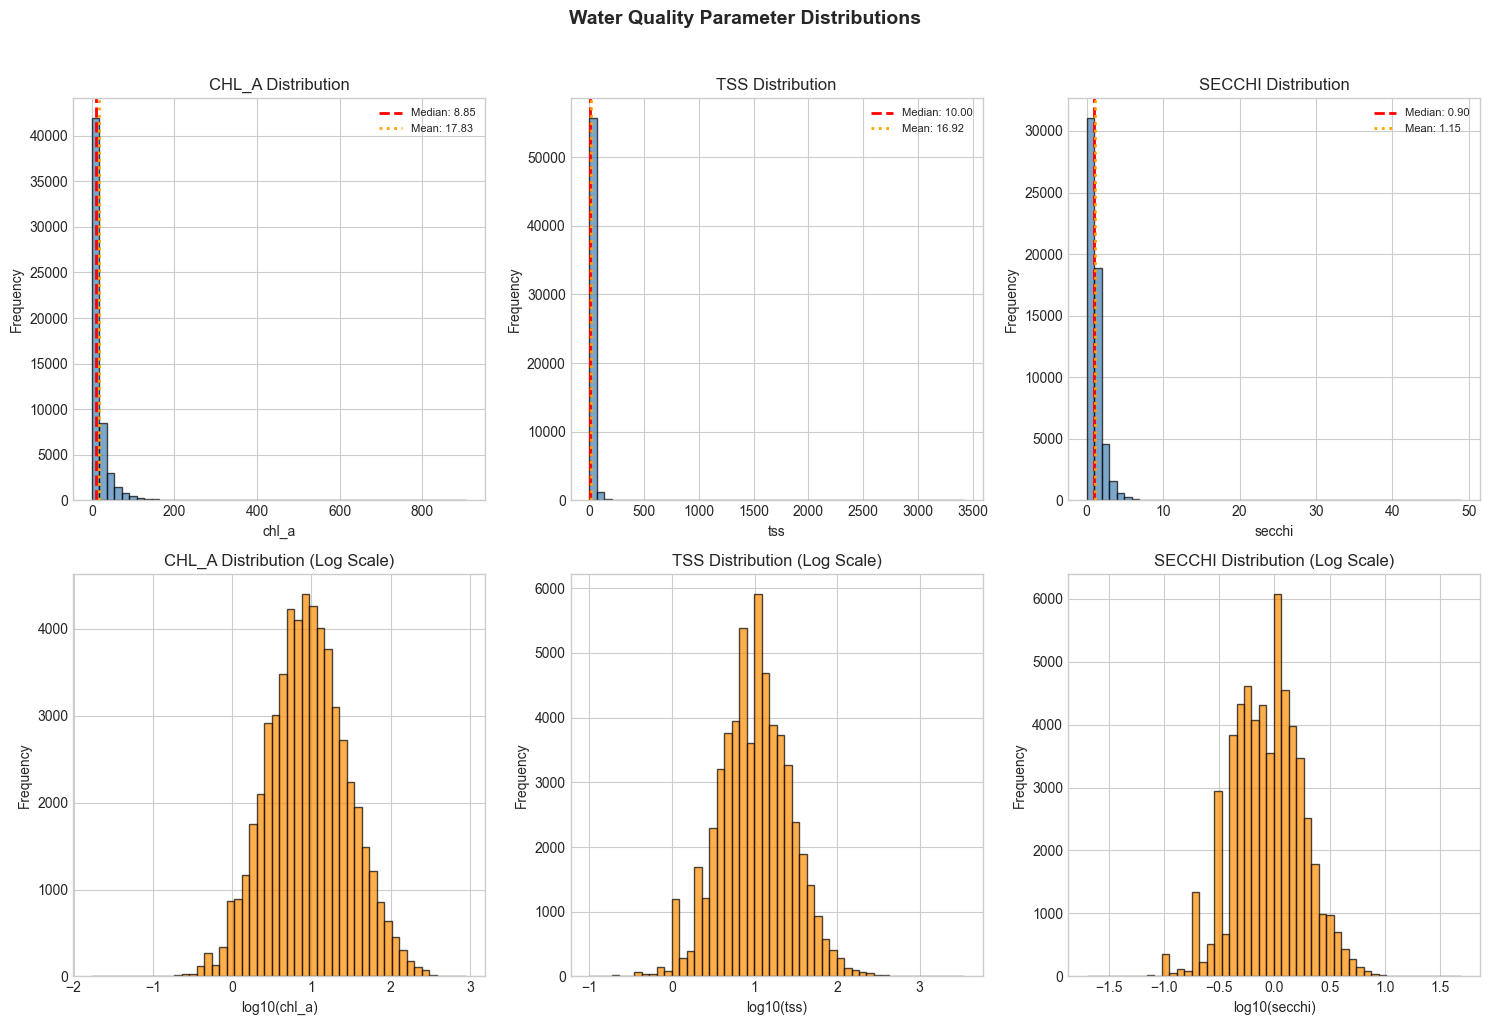

In [13]:
# Visualize target variable distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histograms (top row)
for i, param in enumerate(TARGET_PARAMS):
    ax = axes[0, i]
    data = df[param].dropna()
    
    # Use log scale for better visualization (many water quality params are log-normal)
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f}')
    ax.axvline(data.mean(), color='orange', linestyle=':', linewidth=2, label=f'Mean: {data.mean():.2f}')
    ax.set_xlabel(param)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{param.upper()} Distribution')
    ax.legend(fontsize=8)

# Log-scale histograms (bottom row)
for i, param in enumerate(TARGET_PARAMS):
    ax = axes[1, i]
    data = df[param].dropna()
    
    # Filter out zeros/negatives for log scale
    data_positive = data[data > 0]
    
    ax.hist(np.log10(data_positive), bins=50, edgecolor='black', alpha=0.7, color='darkorange')
    ax.set_xlabel(f'log10({param})')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{param.upper()} Distribution (Log Scale)')

plt.suptitle('Water Quality Parameter Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

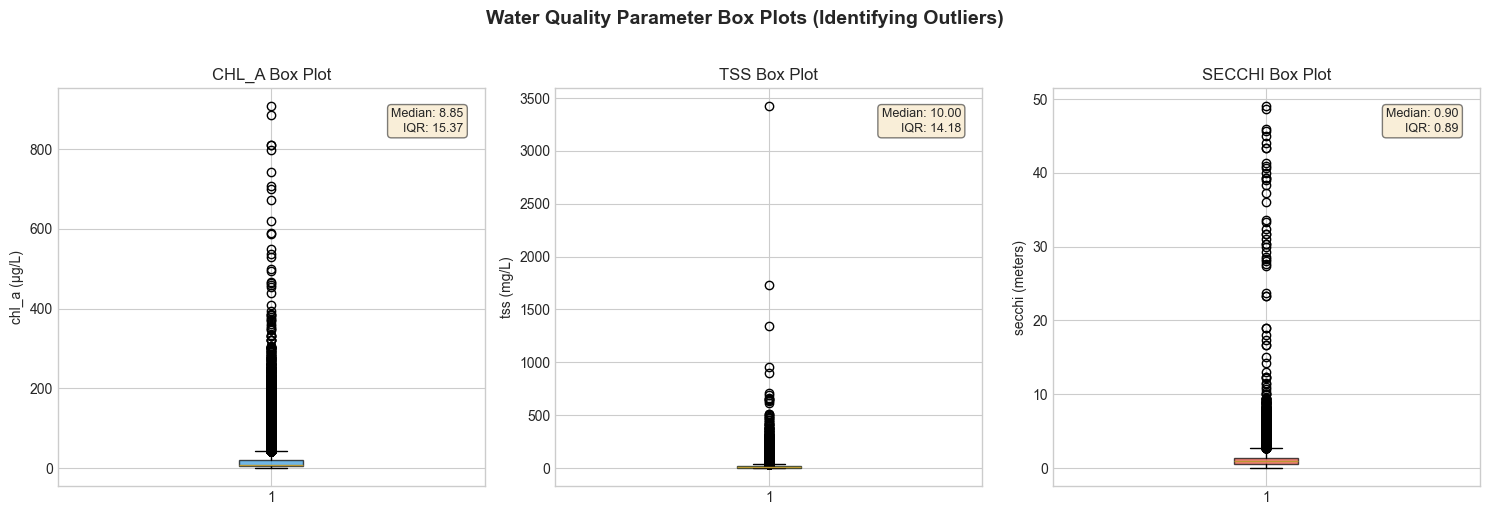

In [14]:
# Box plots to identify outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
units = ['μg/L', 'mg/L', 'meters']

for i, (param, color, unit) in enumerate(zip(TARGET_PARAMS, colors, units)):
    ax = axes[i]
    bp = ax.boxplot(df[param].dropna(), patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    
    ax.set_ylabel(f'{param} ({unit})')
    ax.set_title(f'{param.upper()} Box Plot')
    
    # Add statistics text
    data = df[param].dropna()
    stats_text = f"Median: {data.median():.2f}\nIQR: {data.quantile(0.75) - data.quantile(0.25):.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Water Quality Parameter Box Plots (Identifying Outliers)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Spectral Feature Statistics

### What we're doing
Examining the satellite-derived spectral features that will be our primary predictors.

### What to verify
- Values are in reasonable ranges for reflectance data
- No extreme outliers that could be sensor errors
- Standard deviations are reasonable

In [15]:
# Summary statistics for spectral bands
print(f"{'='*60}")
print(f"SPECTRAL BAND SUMMARY STATISTICS")
print(f"{'='*60}")

spectral_stats = df[SPECTRAL_BANDS].describe()
print("\n")
spectral_stats

SPECTRAL BAND SUMMARY STATISTICS




,blue,green,red,nir,swir1,swir2
count,57268.000,57268.000,57268.000,57268.000,57268.000,57268.000
mean,439.166,532.139,426.895,384.686,181.098,132.541
std,669.192,553.303,583.206,416.525,291.504,195.197
min,2.000,37.000,0.000,0.000,0.000,0.000
25%,281.000,343.000,247.000,198.000,63.000,43.000
50%,382.000,482.000,362.000,310.000,119.000,82.000
75%,510.000,649.000,520.000,489.000,222.000,159.000
max,20000.000,20000.000,20000.000,20000.000,20000.000,6249.000


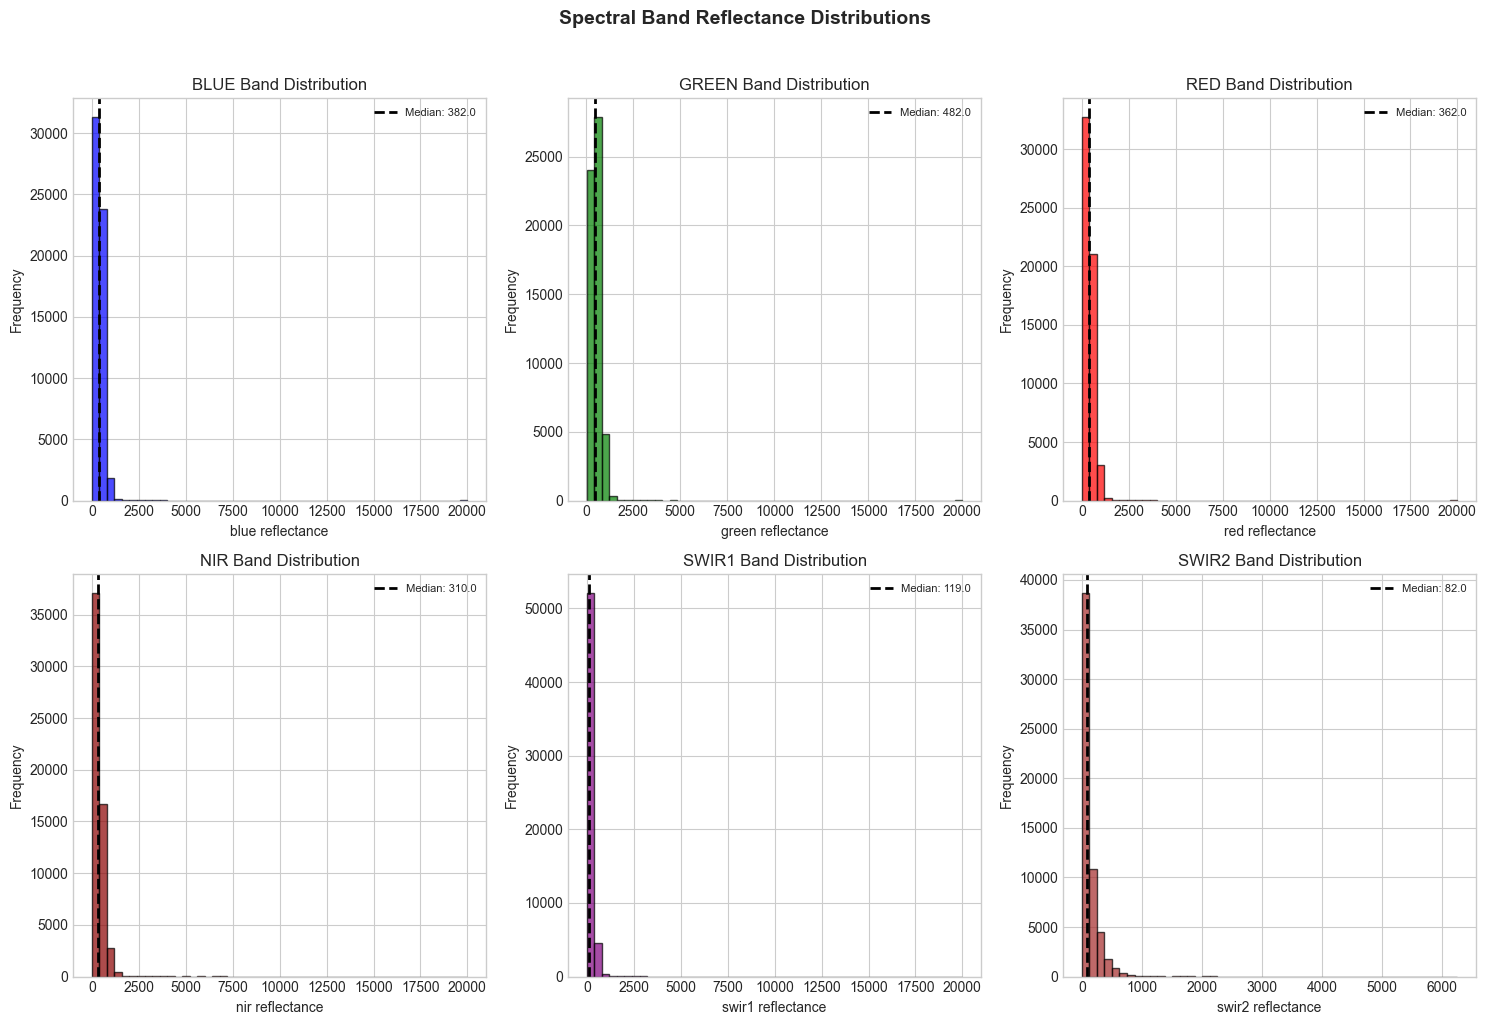

In [16]:
# Visualize spectral band distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

band_colors = ['blue', 'green', 'red', 'darkred', 'purple', 'brown']

for i, (band, color) in enumerate(zip(SPECTRAL_BANDS, band_colors)):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    data = df[band].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=2, label=f'Median: {data.median():.1f}')
    ax.set_xlabel(f'{band} reflectance')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{band.upper()} Band Distribution')
    ax.legend(fontsize=8)

plt.suptitle('Spectral Band Reflectance Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


SPECTRAL BAND CORRELATION MATRIX


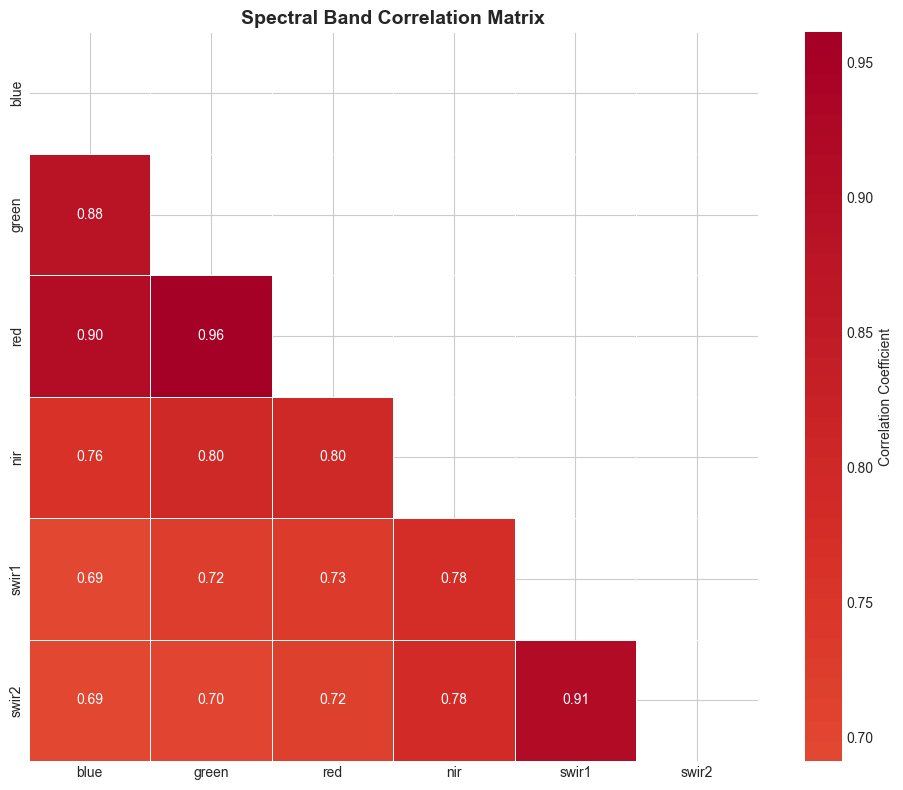

In [17]:
# Correlation between spectral bands
print(f"\n{'='*60}")
print(f"SPECTRAL BAND CORRELATION MATRIX")
print(f"{'='*60}")

spectral_corr = df[SPECTRAL_BANDS].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(spectral_corr, dtype=bool))
sns.heatmap(spectral_corr, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, fmt='.2f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Spectral Band Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Temporal and Spatial Coverage

### What we're doing
Understanding the temporal and spatial extent of our dataset.

### Why this matters
- Ensures sufficient data across seasons (for seasonal analysis)
- Confirms geographic diversity
- Identifies potential biases in sampling

In [18]:
# Temporal coverage
print(f"{'='*60}")
print(f"TEMPORAL COVERAGE ANALYSIS")
print(f"{'='*60}")

# Year range
print(f"\n📅 Year Range: {df['year'].min()} - {df['year'].max()}")
print(f"   Total years: {df['year'].nunique()}")

# Month distribution
print(f"\n📊 Monthly Distribution:")
month_counts = df['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, count in month_counts.items():
    pct = count / len(df) * 100
    print(f"   {month_names[int(month)-1]}: {count:,} ({pct:.1f}%)")

TEMPORAL COVERAGE ANALYSIS

📅 Year Range: 1984 - 2019
   Total years: 36

📊 Monthly Distribution:
   Jan: 2,470 (4.3%)
   Feb: 3,053 (5.3%)
   Mar: 3,686 (6.4%)
   Apr: 5,054 (8.8%)
   May: 6,351 (11.1%)
   Jun: 6,178 (10.8%)
   Jul: 7,360 (12.9%)
   Aug: 7,647 (13.4%)
   Sep: 6,003 (10.5%)
   Oct: 4,158 (7.3%)
   Nov: 3,020 (5.3%)
   Dec: 2,288 (4.0%)


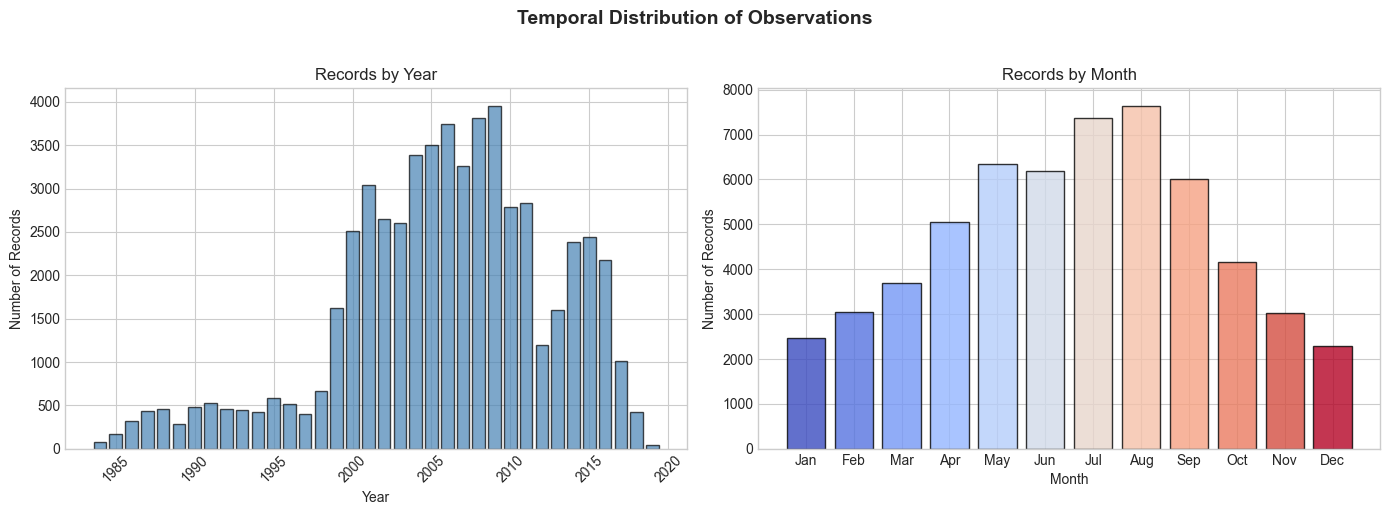

In [19]:
# Seasonal distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly distribution
ax1 = axes[0]
year_counts = df['year'].value_counts().sort_index()
ax1.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Records')
ax1.set_title('Records by Year')
ax1.tick_params(axis='x', rotation=45)

# Monthly distribution
ax2 = axes[1]
month_counts = df['month'].value_counts().sort_index()
colors = plt.cm.coolwarm(np.linspace(0, 1, 12))  # Cold to warm colors by month
ax2.bar(range(1, 13), month_counts.reindex(range(1, 13)).fillna(0).values, 
        color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Records')
ax2.set_title('Records by Month')

plt.suptitle('Temporal Distribution of Observations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

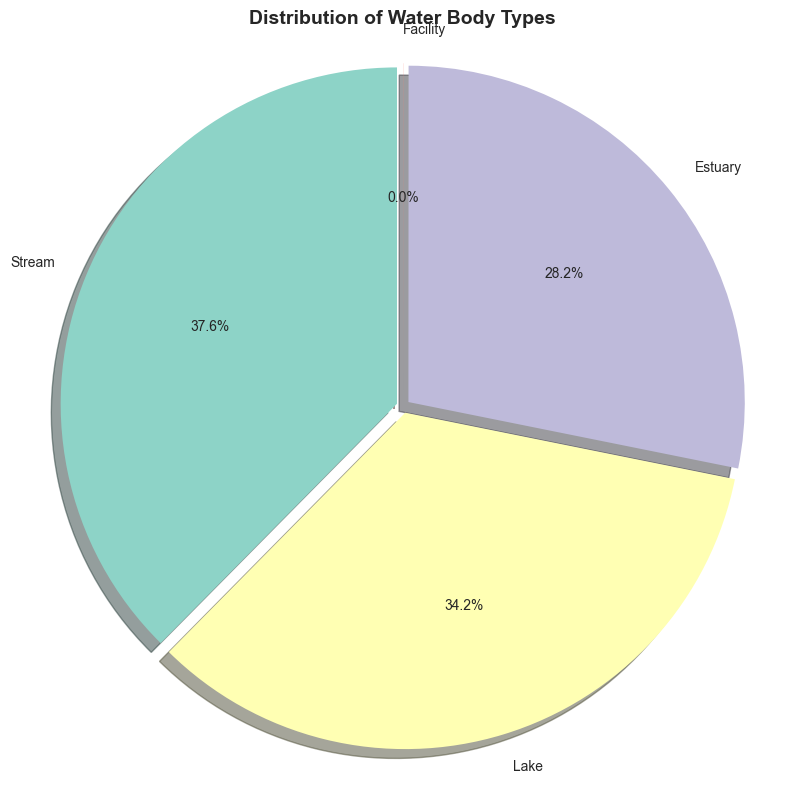

In [23]:
plt.figure(figsize=(8, 8))

colors = plt.cm.Set3.colors[:len(type_counts)]
explode = [0.02] * len(type_counts)

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)

plt.title('Distribution of Water Body Types', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()



GEOGRAPHIC COVERAGE

📍 Latitude Range: 25.1410 to 66.4880
📍 Longitude Range: -155.1078 to -71.0664

🗺️ Unique Sites: 10,865


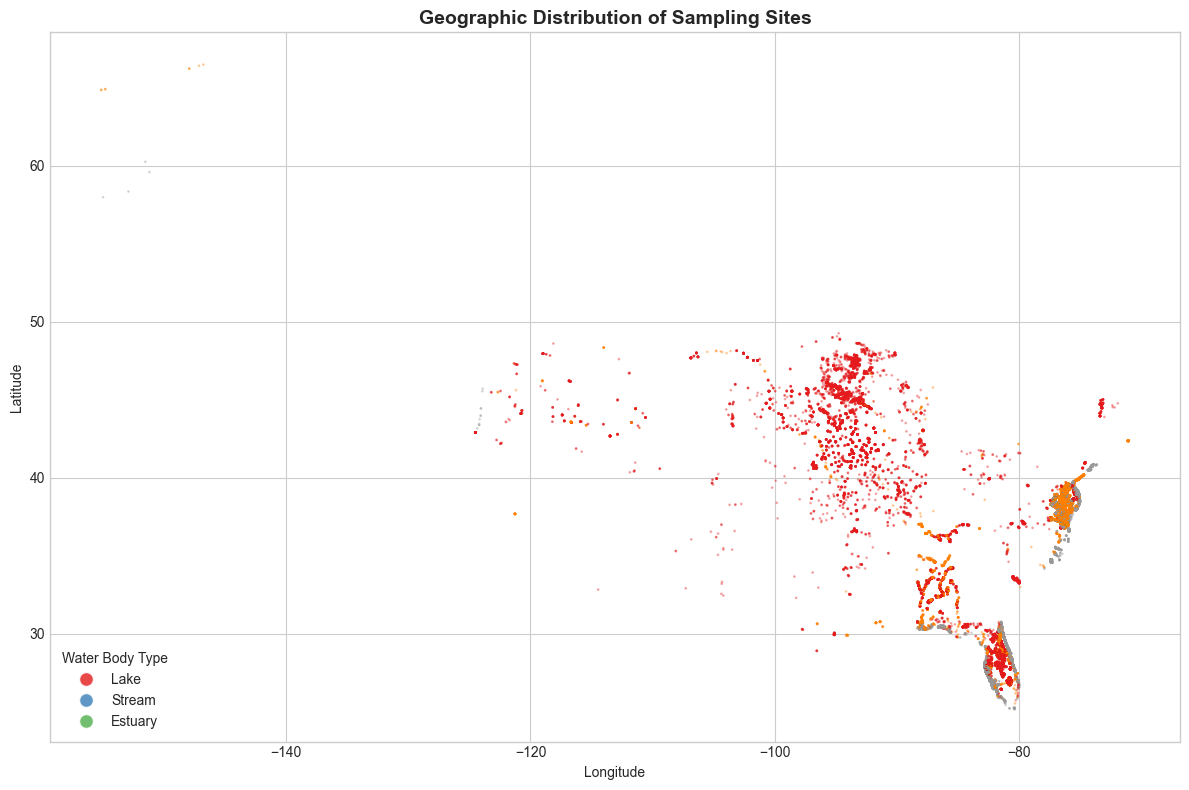

In [24]:
# Geographic coverage
print(f"\n{'='*60}")
print(f"GEOGRAPHIC COVERAGE")
print(f"{'='*60}")

print(f"\n📍 Latitude Range: {df['lat'].min():.4f} to {df['lat'].max():.4f}")
print(f"📍 Longitude Range: {df['long'].min():.4f} to {df['long'].max():.4f}")
print(f"\n🗺️ Unique Sites: {df['SiteID'].nunique():,}")

# Scatter plot of locations
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['long'], df['lat'], c=df['type'].map({'Lake': 0, 'Stream': 1, 'Estuary': 2}),
                      cmap='Set1', alpha=0.3, s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Sampling Sites', fontsize=14, fontweight='bold')

# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, alpha=0.8)
           for c in ['#e41a1c', '#377eb8', '#4daf4a']]
plt.legend(handles, ['Lake', 'Stream', 'Estuary'], title='Water Body Type', loc='lower left')

plt.tight_layout()
plt.show()

## 8. Satellite Coverage

### What we're doing
Understanding which Landsat satellites contributed to the dataset.

### Why this matters
- Different satellites have slightly different sensors
- May need to account for satellite-specific biases
- Important for temporal analysis (different satellites cover different periods)

SATELLITE PLATFORM DISTRIBUTION

🛰️ Satellite Platforms:
   Landsat 7 (ETM+): 26,464 (46.2%)
   Landsat 5 (TM): 25,992 (45.4%)
   Landsat 8 (OLI): 4,812 (8.4%)


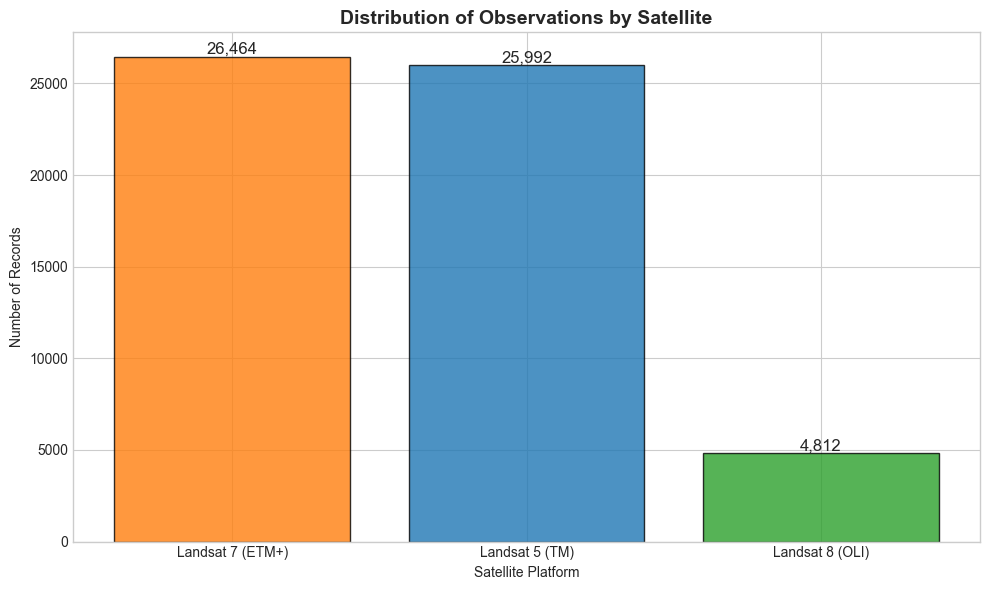

In [25]:
# Satellite distribution
print(f"{'='*60}")
print(f"SATELLITE PLATFORM DISTRIBUTION")
print(f"{'='*60}")

sat_counts = df['sat'].value_counts()
sat_names = {5: 'Landsat 5 (TM)', 7: 'Landsat 7 (ETM+)', 8: 'Landsat 8 (OLI)'}

print("\n🛰️ Satellite Platforms:")
for sat, count in sat_counts.items():
    pct = count / len(df) * 100
    name = sat_names.get(sat, f'Satellite {sat}')
    print(f"   {name}: {count:,} ({pct:.1f}%)")

# Bar chart
plt.figure(figsize=(10, 6))
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']
bars = plt.bar([sat_names.get(s, f'Sat {s}') for s in sat_counts.index], 
               sat_counts.values, color=colors[:len(sat_counts)], edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=12)

plt.xlabel('Satellite Platform')
plt.ylabel('Number of Records')
plt.title('Distribution of Observations by Satellite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Data Quality Summary & Sanity Checks

### What we're doing
Final verification that the dataset is suitable for modeling.

### Checks performed
- No duplicate records
- Target values within scientifically reasonable ranges
- Spectral values are positive and reasonable
- No obvious data corruption

In [26]:
# Comprehensive sanity checks
print(f"{'='*60}")
print(f"DATA QUALITY SANITY CHECKS")
print(f"{'='*60}")

# Check 1: Duplicate records
duplicates = df.duplicated().sum()
print(f"\n1️⃣ Duplicate Records: {duplicates}")
if duplicates == 0:
    print("   ✅ No duplicate records found")
else:
    print(f"   ⚠️ {duplicates} duplicate records found")

# Check 2: Target value ranges
print(f"\n2️⃣ Target Value Range Checks:")

# chl_a: typically 0-500 μg/L, can be higher in blooms
chl_a_valid = (df['chl_a'] >= 0) & (df['chl_a'] <= 2000)
print(f"   • chl_a: {chl_a_valid.sum():,} valid ({chl_a_valid.mean()*100:.1f}%), " +
      f"Range: {df['chl_a'].min():.2f} - {df['chl_a'].max():.2f}")

# tss: typically 0-500 mg/L, can be higher in turbid waters
tss_valid = (df['tss'] >= 0) & (df['tss'] <= 5000)
print(f"   • tss: {tss_valid.sum():,} valid ({tss_valid.mean()*100:.1f}%), " +
      f"Range: {df['tss'].min():.2f} - {df['tss'].max():.2f}")

# secchi: typically 0-40 meters
secchi_valid = (df['secchi'] >= 0) & (df['secchi'] <= 50)
print(f"   • secchi: {secchi_valid.sum():,} valid ({secchi_valid.mean()*100:.1f}%), " +
      f"Range: {df['secchi'].min():.2f} - {df['secchi'].max():.2f}")

# Check 3: Spectral band values
print(f"\n3️⃣ Spectral Band Value Checks:")
for band in SPECTRAL_BANDS:
    negative_count = (df[band] < 0).sum()
    zero_count = (df[band] == 0).sum()
    max_val = df[band].max()
    print(f"   • {band}: {negative_count} negative, {zero_count} zero, max={max_val:.1f}")

# Check 4: Coordinate validity
print(f"\n4️⃣ Coordinate Validity:")
lat_valid = (df['lat'] >= -90) & (df['lat'] <= 90)
long_valid = (df['long'] >= -180) & (df['long'] <= 180)
print(f"   • Valid latitudes: {lat_valid.sum():,} ({lat_valid.mean()*100:.1f}%)")
print(f"   • Valid longitudes: {long_valid.sum():,} ({long_valid.mean()*100:.1f}%)")

DATA QUALITY SANITY CHECKS

1️⃣ Duplicate Records: 0
   ✅ No duplicate records found

2️⃣ Target Value Range Checks:
   • chl_a: 57,268 valid (100.0%), Range: 0.02 - 907.00
   • tss: 57,268 valid (100.0%), Range: 0.10 - 3420.00
   • secchi: 57,268 valid (100.0%), Range: 0.00 - 49.00

3️⃣ Spectral Band Value Checks:
   • blue: 0 negative, 0 zero, max=20000.0
   • green: 0 negative, 0 zero, max=20000.0
   • red: 0 negative, 1 zero, max=20000.0
   • nir: 0 negative, 1 zero, max=20000.0
   • swir1: 0 negative, 13 zero, max=20000.0
   • swir2: 0 negative, 23 zero, max=6249.0

4️⃣ Coordinate Validity:
   • Valid latitudes: 57,268 (100.0%)
   • Valid longitudes: 57,268 (100.0%)


In [27]:
# Final summary
print(f"\n{'='*60}")
print(f"📋 FINAL DATASET SUMMARY")
print(f"{'='*60}")

print(f"""
📊 DATASET CHARACTERISTICS:
   • Total Records: {len(df):,}
   • Total Features: {len(df.columns)}
   • Date Range: {df['year'].min()} - {df['year'].max()}
   • Unique Sites: {df['SiteID'].nunique():,}
   
🎯 TARGET PARAMETERS (All Complete):
   • chl_a: {df['chl_a'].min():.2f} - {df['chl_a'].max():.2f} μg/L (median: {df['chl_a'].median():.2f})
   • tss: {df['tss'].min():.2f} - {df['tss'].max():.2f} mg/L (median: {df['tss'].median():.2f})
   • secchi: {df['secchi'].min():.2f} - {df['secchi'].max():.2f} m (median: {df['secchi'].median():.2f})
   
🌈 SPECTRAL BANDS (6 primary features):
   • blue, green, red, nir, swir1, swir2
   
🌊 WATER BODY TYPES:
   • Lakes: {(df['type'] == 'Lake').sum():,}
   • Streams: {(df['type'] == 'Stream').sum():,}
   • Estuaries: {(df['type'] == 'Estuary').sum():,}
""")


📋 FINAL DATASET SUMMARY

📊 DATASET CHARACTERISTICS:
   • Total Records: 57,268
   • Total Features: 45
   • Date Range: 1984 - 2019
   • Unique Sites: 10,865
   
🎯 TARGET PARAMETERS (All Complete):
   • chl_a: 0.02 - 907.00 μg/L (median: 8.85)
   • tss: 0.10 - 3420.00 mg/L (median: 10.00)
   • secchi: 0.00 - 49.00 m (median: 0.90)
   
🌈 SPECTRAL BANDS (6 primary features):
   • blue, green, red, nir, swir1, swir2
   
🌊 WATER BODY TYPES:
   • Lakes: 19,606
   • Streams: 21,532
   • Estuaries: 16,126

